# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
import pandas as pd

# Load CSV
df = pd.read_csv("tweet_sentiment_train.csv.zip", compression="zip") # locally
#df = pd.read_csv("/content/drive/MyDrive/DS_ML/tweet_sentiment_train.csv.zip", compression="zip") # gdrive

# Show basic info
print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

# Display first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()
print("\nShape after dropping missing values:", df.shape)


Dataset shape: (27481, 4)

Column types:
textID           object
text             object
selected_text    object
sentiment        object
dtype: object

First 5 rows:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative



Missing values per column:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

Shape after dropping missing values: (27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



Class distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


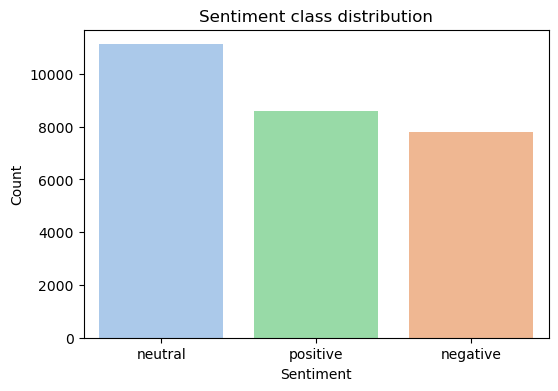


Text length statistics:
count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64


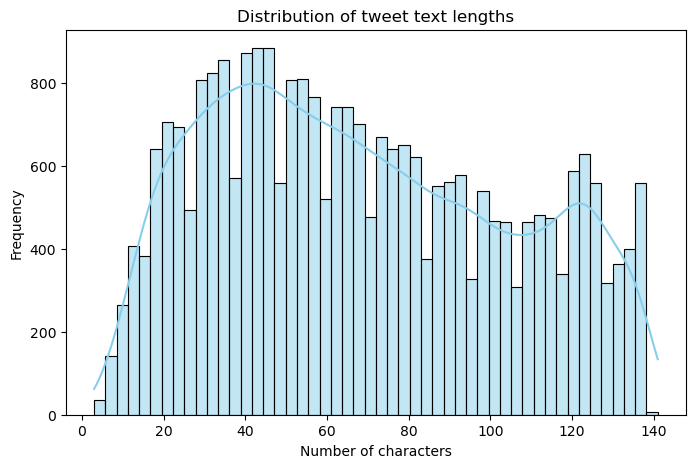

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of sentiment classes
print("Class distribution:")
print(df["sentiment"].value_counts())

# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment", hue="sentiment", legend=False, order=df["sentiment"].value_counts().index, palette="pastel")
plt.title("Sentiment class distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# 2. Calculate text lengths
df["text_length"] = df["text"].apply(len)

# Display basic statistics for text lengths
print("\nText length statistics:")
print(df["text_length"].describe())

# Plot distribution of text lengths
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50, kde=True, color="skyblue")
plt.title("Distribution of tweet text lengths")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()


### Висновок

У наборі даних є три класи сентименту: neutral, positive та negative.  
Найбільше твітів належить до класу neutral (11 тис.), менше до positive (8,5 тис.), і найменше до negative (7,8 тис.).  
Класи мають певний дисбаланс, але він не є критичним для побудови базової моделі.

Розподіл довжин текстів показує, що більшість твітів мають довжину близько 60–100 символів.  
Короткі пости (менше 40 символів) також досить поширені, тоді як довгі зустрічаються рідко.  
Це очікувано, адже твіти зазвичай лаконічні й обмежені за кількістю символів.


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [8]:
# A - external preprocessing, then CountVectorizer

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Ensure stopwords are available
nltk.download('stopwords', quiet=True)

# Init tools
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

# Preprocess function
def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', ' ', text)  # remove urls, mentions, '#'
    text = re.sub(r"[^a-z\s']", ' ', text)             # keep letters and apostrophes
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

# Vectorize
vectorizer_a = CountVectorizer(max_features=10000, min_df=2)
X_bow_a = vectorizer_a.fit_transform(df['clean_text'])
y = df['sentiment'].values

print("A) BOW shape:", X_bow_a.shape)
print("A) Sample features:", vectorizer_a.get_feature_names_out()[:20])


A) BOW shape: (27480, 7882)
A) Sample features: ['aaaa' 'aaaah' 'aaah' 'aaahhh' 'aaaw' 'aaawww' 'aah' 'aargh' 'aaron' 'ab'
 'abandon' 'abbey' 'abbi' 'abbrevi' 'abc' 'abi' 'abid' 'abil' 'abit' 'abl']


In [9]:
# B1 - built-in preprocessing inside CountVectorizer (no stemming)

from sklearn.feature_extraction.text import CountVectorizer

# Token pattern keeps alphabetic tokens and apostrophes
vectorizer_b1 = CountVectorizer(
    stop_words='english',
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
    max_features=10000,
    min_df=2
)

X_bow_b1 = vectorizer_b1.fit_transform(df['text'])
y = df['sentiment'].values

print("B1) BOW shape:", X_bow_b1.shape)
print("B1) Sample features:", vectorizer_b1.get_feature_names_out()[:20])


B1) BOW shape: (27480, 9456)
B1) Sample features: ['aaaa' 'aaaah' 'aaah' 'aaahhh' 'aaaw' 'aaawww' 'aah' 'aargh' 'aaron' 'ab'
 'abandoned' 'abandoning' 'abbey' 'abby' 'abc' 'abiding' 'ability' 'abit'
 'able' 'aboard']


In [10]:
# B2: custom analyzer inside CountVectorizer (with stemming)

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Ensure stopwords are available
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

url_pat = re.compile(r'https?://\S+|www\.\S+')
mention_pat = re.compile(r'@\w+')
hash_pat = re.compile(r'#')
non_letter_pat = re.compile(r"[^a-z']+")

def analyzer_b2(doc: str):
    if not isinstance(doc, str):
        return []
    doc = doc.lower()
    doc = url_pat.sub(' ', doc)
    doc = mention_pat.sub(' ', doc)
    doc = hash_pat.sub('', doc)
    doc = non_letter_pat.sub(' ', doc)
    toks = [w for w in doc.split() if w not in stop_words and len(w) > 1]
    return [stemmer.stem(w) for w in toks]

vectorizer_b2 = CountVectorizer(
    analyzer=analyzer_b2,
    max_features=10000,
    min_df=2
)

X_bow_b2 = vectorizer_b2.fit_transform(df['text'])
y = df['sentiment'].values

print("B2) BOW shape:", X_bow_b2.shape)
print("B2) Sample features:", vectorizer_b2.get_feature_names_out()[:20])


B2) BOW shape: (27480, 7893)
B2) Sample features: ["'a" "'i" 'aaaa' 'aaaah' 'aaah' 'aaahhh' 'aaaw' 'aaawww' 'aah' 'aargh'
 'aaron' 'ab' 'abandon' 'abbey' 'abbi' 'abbrevi' 'abc' 'abi' 'abid' 'abil']


In [11]:
#  Compare vectorizations: basic stats
import numpy as np

def sparsity_info(X):
    nnz = X.nnz
    total = X.shape[0] * X.shape[1]
    return 1.0 - (nnz / total)

for name, X in {
    "A": X_bow_a,
    "B1": X_bow_b1,
    "B2": X_bow_b2
}.items():
    print(f"{name}: shape={X.shape}, features={X.shape[1]}, sparsity={sparsity_info(X):.4f}")


A: shape=(27480, 7882), features=7882, sparsity=0.9992
B1: shape=(27480, 9456), features=9456, sparsity=0.9994
B2: shape=(27480, 7893), features=7893, sparsity=0.9992


In [12]:
#  Cross-validated comparison (same splits)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=None),
    "LinearSVC": LinearSVC(),
    "MultinomialNB": MultinomialNB()
}

results = []
for vec_name, X in {"A": X_bow_a, "B1": X_bow_b1, "B2": X_bow_b2}.items():
    for mdl_name, mdl in models.items():
        scores = cross_validate(
            mdl, X, y,
            cv=cv,
            scoring=["accuracy", "f1_macro"],
            n_jobs=-1,
            return_train_score=False
        )
        results.append({
            "Vectorizer": vec_name,
            "Model": mdl_name,
            "ACC_mean": scores["test_accuracy"].mean(),
            "ACC_std": scores["test_accuracy"].std(),
            "F1_macro_mean": scores["test_f1_macro"].mean(),
            "F1_macro_std": scores["test_f1_macro"].std()
        })

cv_df = pd.DataFrame(results).sort_values(["F1_macro_mean","ACC_mean"], ascending=False)
cv_df


,Vectorizer,Model,ACC_mean,ACC_std,F1_macro_mean,F1_macro_std
6,B2,LogReg,0.691230,0.003202,0.691269,0.002679
0,A,LogReg,0.690975,0.003332,0.690948,0.003006
3,B1,LogReg,0.689702,0.005095,0.690021,0.004841
1,A,LinearSVC,0.661245,0.004457,0.662016,0.004066
7,B2,LinearSVC,0.659680,0.004924,0.660461,0.004393
4,B1,LinearSVC,0.657096,0.004398,0.658251,0.004528
2,A,MultinomialNB,0.651237,0.003184,0.653195,0.003485
8,B2,MultinomialNB,0.650910,0.003217,0.652863,0.003475
5,B1,MultinomialNB,0.647162,0.003548,0.649130,0.003986


### Висновок

Три способи векторизації BoW:  
- **A** - зовнішня попередня обробка (очистка + stopwords + стемінг) - `CountVectorizer`.  
- **B1** - лише вбудовані можливості `CountVectorizer` (stopwords + налаштований `token_pattern`, без стемінгу).  
- **B2** - кастомний `analyzer` усередині `CountVectorizer` (очистка + stopwords + стемінг).

**Результати (5-fold CV, F1_macro  краще):**  
- **B2 + LogisticRegression**: ~**0.6913** (найкраще, але з мінімальною перевагою).  
- **A + LogisticRegression**: ~0.6910.  
- **B1 + LogisticRegression**: ~0.6900.  
Різниця між трьома підходами дуже мала і близька до межі статистичної похибки (див. std).

**Розмір словника та розрідженість:**  
- A: ~7 882 фіч;
- B1: ~9 456 фіч;
- B2: ~7 893 фіч.  
- Усі матриці дуже розріджені (≈0.999), що типово для BoW.

**Інтерпретація:**  
- **Стемінг** (A та B2) дає невеликий плюс vs. варіант без стемінгу (B1).  
- **B2** зручно тримає всю обробку в одному об’єкті та показує найвищий F1_macro,  
  але **A** дає майже ідентичний результат і простіше дебажити кроки обробки.

**Висновок:**  
Для подальших кроків можна обрати **B2 + LogisticRegression** як базову конфігурацію (найкращий F1_macro),  
або **A + LogisticRegression** як простішу й прозорішу альтернативу з майже такою самою якістю.



### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [15]:
import numpy as np
from sklearn.model_selection import train_test_split

# Choose the vectorized matrix (switch to X_bow_a or X_bow_b1 if needed)
X_bow = X_bow_b2
labels = y  # from previous steps

# Stratified split to preserve class ratios
train_idx, test_idx = train_test_split(
    np.arange(X_bow.shape[0]),
    test_size=0.3,
    random_state=42,
    stratify=labels
)

X_train_bow = X_bow[train_idx]
X_test_bow  = X_bow[test_idx]
y_train = labels[train_idx]
y_test  = labels[test_idx]

X_train_bow.shape, X_test_bow.shape


((19236, 7893), (8244, 7893))

In [16]:
# Task 4.2: Train several classifiers and pick the best by F1_macro
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, f1_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, solver="liblinear"),
    "LinearSVC": LinearSVC(),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB()
}

perf = []
best_name, best_model, best_f1 = None, None, -1.0

for name, clf in models.items():
    clf.fit(X_train_bow, y_train)
    pred = clf.predict(X_test_bow)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")
    perf.append((name, acc, f1m))
    if f1m > best_f1:
        best_name, best_model, best_f1 = name, clf, f1m

print("Test set results:")
for name, acc, f1m in sorted(perf, key=lambda x: x[2], reverse=True):
    print(f"{name:16s}  ACC={acc:.4f}  F1_macro={f1m:.4f}")

print(f"\nSelected best model: {best_name} (F1_macro={best_f1:.4f})")


Test set results:
LogisticRegression  ACC=0.6862  F1_macro=0.6867
LinearSVC         ACC=0.6562  F1_macro=0.6578
MultinomialNB     ACC=0.6447  F1_macro=0.6475
ComplementNB      ACC=0.6308  F1_macro=0.6321

Selected best model: LogisticRegression (F1_macro=0.6867)


Classification report (per class):
              precision    recall  f1-score   support

    negative     0.7038    0.6148    0.6563      2334
     neutral     0.6358    0.7151    0.6732      3335
    positive     0.7486    0.7134    0.7306      2575

    accuracy                         0.6862      8244
   macro avg     0.6961    0.6811    0.6867      8244
weighted avg     0.6903    0.6862    0.6863      8244



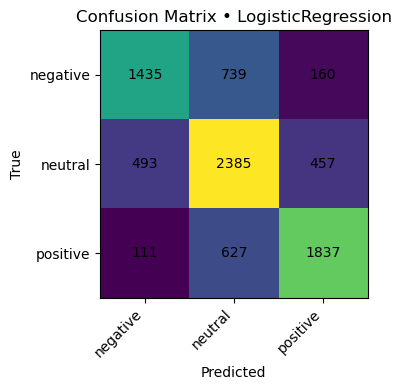

In [17]:
# Detailed evaluation of the selected best model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = best_model.predict(X_test_bow)

print("Classification report (per class):")
print(classification_report(y_test, y_pred, digits=4))

labels_sorted = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix • {best_name}")
plt.xticks(ticks=range(len(labels_sorted)), labels=labels_sorted, rotation=45, ha="right")
plt.yticks(ticks=range(len(labels_sorted)), labels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


### Висновок

Модель: LogisticRegression (OvR)  
Якість на тесті: Accuracy ≈ 0.686, F1_macro ≈ 0.687  

Per-class (F1):  
- positive: ~0.731 — найкраще розпізнається (precision ~0.75, recall ~0.71)  
- neutral: ~ 0.673 — середня якість; високий recall ( 0.72), нижча precision (~0.64)  
- negative: ~0.656 — найскладніший клас (recall ~0.61)  

Confusion matrix (основні помилки):  
- Багато neutral - positive/negative: з neutral у negative (493) і positive (457)  
  з positive у neutral (627); з negative у neutral (739)  
  Тобто клас neutral — головне джерело помилок.  

Оцінка: для базового підходу на BoW результат нормальний (~0.69 F1_macro) і близький до SGD-бейслайну, з бонусом кращої інтерпретованості коефіцієнтів  




### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = LogisticRegression(max_iter=2000, solver="sag")
logreg.fit(X_train_bow, y_train)
print(classification_report(y_test, logreg.predict(X_test_bow), digits=4))


              precision    recall  f1-score   support

    negative     0.7003    0.6157    0.6553      2334
     neutral     0.6303    0.7151    0.6700      3335
    positive     0.7504    0.7017    0.7253      2575

    accuracy                         0.6828      8244
   macro avg     0.6937    0.6775    0.6835      8244
weighted avg     0.6876    0.6828    0.6831      8244



In [21]:
# Extract feature names and class-wise coefficients
import numpy as np

vec = vectorizer_b2  # or vectorizer_a / vectorizer_b1 (must match X_*)
feature_names = np.array(vec.get_feature_names_out())
classes = np.array(logreg.classes_)      # e.g., ['negative','neutral','positive']
coef = logreg.coef_                      # shape: (n_classes, n_features)
coef.shape, classes


((3, 7893), array(['negative', 'neutral', 'positive'], dtype=object))

In [22]:
#  Top-k influential tokens for each class
import numpy as np
import pandas as pd

def top_tokens_for_class(coef_row, feature_names, k=20):
    """Return top +k and -k tokens for a one-vs-rest class."""
    pos_idx = np.argsort(coef_row)[::-1][:k]   # strongest positive weights
    neg_idx = np.argsort(coef_row)[:k]         # strongest negative weights
    df_pos = pd.DataFrame({"token": feature_names[pos_idx], "weight": coef_row[pos_idx], "direction": "pro-class"})
    df_neg = pd.DataFrame({"token": feature_names[neg_idx], "weight": coef_row[neg_idx], "direction": "anti-class"})
    return pd.concat([df_pos, df_neg], ignore_index=True)

top_k = 20
top_tables_lr = {cls: top_tokens_for_class(coef[i], feature_names, k=top_k)
                 for i, cls in enumerate(classes)}

for cls, tbl in top_tables_lr.items():
    print(f"\n=== Class: {cls} ===")
    display(tbl.sort_values(["direction", "weight"], ascending=[False, False]))



=== Class: negative ===


,token,weight,direction
0,sad,2.539046,pro-class
1,suck,2.516590,pro-class
2,sorri,2.402989,pro-class
3,hate,2.313840,pro-class
4,bore,2.293414,pro-class
5,miss,2.150531,pro-class
6,stupid,2.112010,pro-class
7,fail,2.054059,pro-class
8,worst,2.035320,pro-class
9,headach,1.980435,pro-class



=== Class: neutral ===


,token,weight,direction
0,indoor,1.540809,pro-class
1,chan,1.365621,pro-class
2,oooo,1.336439,pro-class
3,jst,1.210872,pro-class
4,parvo,1.208722,pro-class
5,raimi,1.206621,pro-class
6,moro,1.168550,pro-class
7,sarcast,1.165822,pro-class
8,england,1.155327,pro-class
9,otherwis,1.148373,pro-class



=== Class: positive ===


,token,weight,direction
0,awesom,2.549483,pro-class
1,cute,2.499388,pro-class
2,thank,2.460078,pro-class
3,love,2.425530,pro-class
4,glad,2.286246,pro-class
5,amaz,2.259268,pro-class
6,nice,2.167302,pro-class
7,gorgeous,2.164858,pro-class
8,congratul,2.142768,pro-class
9,excit,2.136141,pro-class


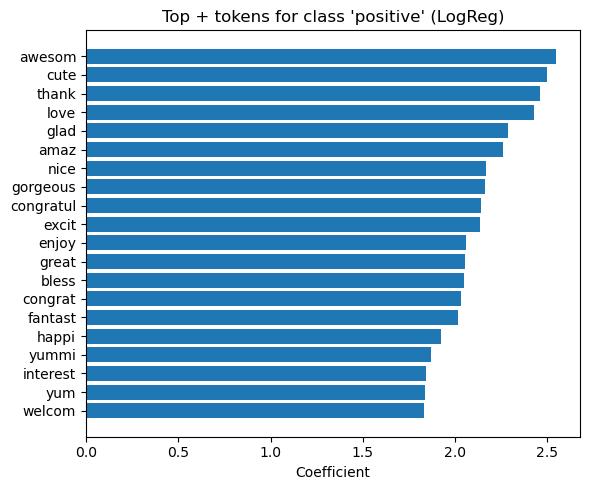

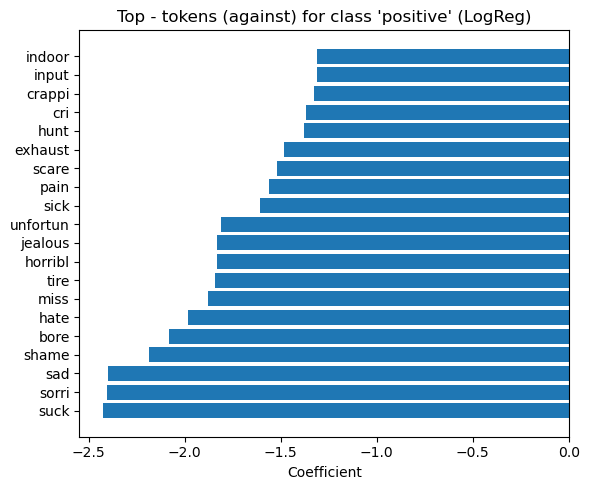

In [23]:
#  Horizontal bar plots for one class
import matplotlib.pyplot as plt

cls_to_plot = "positive"  # 'neutral' or 'negative'
tbl = top_tables_lr[cls_to_plot]
pro = tbl[tbl["direction"]=="pro-class"].sort_values("weight", ascending=True)
anti = tbl[tbl["direction"]=="anti-class"].sort_values("weight", ascending=True)

plt.figure(figsize=(6,5))
plt.barh(pro["token"], pro["weight"])
plt.title(f"Top + tokens for class '{cls_to_plot}' (LogReg)")
plt.xlabel("Coefficient")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.barh(anti["token"], anti["weight"])
plt.title(f"Top - tokens (against) for class '{cls_to_plot}' (LogReg)")
plt.xlabel("Coefficient")
plt.tight_layout(); plt.show()


### Висновок

Що показали коефіцієнти (OvR):  
- positive (топ “за” клас): `awesom, cute, thank, love, glad, amaz, nice, gorgeous, congratul/congrat, excit, enjoy, great, bless, fantast, happi, yummi, yum, welcom…`  
  “Проти” positive: `suck, sorri, sad, shame, bore, hate, miss, tire, horribl, jealous, unfortun, sick, pain, exhaust…`
- negative (симетрично): вагомі “за” — негативно забарвлена лексика на приклад: `suck, hate, sad, sorri, bore, pain, sick, angr…`; “проти” — позитивні маркери (`love, great, thank…`).
- neutral (топ “за”): багато тематичних, іменних або нейтральних токенів та вигуків:  
  `indoor, chan, oooo, jst, parvo, raimi, moro, sarcast, england, otherwis, hummmmm, pearl, sp, plz, grade, guitar, twhirl, tile, spew, avail…`  
  “Проти” neutral з’являються слова з явною емоційністю: `frustrat, sweeti, sober, …` (і далі — типові позитив/негатив).

Чи це логічно?  
- Для positive/negative — так, модель підхопила класичні емоційні маркери; знак і величина коефіцієнтів відповідають очікуванням.  
- Для neutral — логічно, що впливові токени мають слабко виражене емоційне забарвлення (імена, місця, вигуки, службові форми, тощо)


Висновок: інтерпретація ваг узгоджується зі здоровим глуздом: позитив/негатив визначається емоційною лексикою, нейтральна — предметними/нейтральними токенами.


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [26]:
#TF-IDF vectorization with the same preprocessing (uses analyzer_b2)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer=analyzer_b2,   # SAME preprocessing as BoW
    max_features=10000,     # keep comparable capacity
    min_df=2                # same rare-word cut
)

X_tfidf = tfidf.fit_transform(df["text"])
y = df["sentiment"].values

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (27480, 7893)


In [27]:
# Assumes train_idx and test_idx were created in Task 4
X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf  = X_tfidf[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

X_train_tfidf.shape, X_test_tfidf.shape


((19236, 7893), (8244, 7893))

Classification report (TF-IDF):
              precision    recall  f1-score   support

    negative     0.7297    0.5900    0.6525      2334
     neutral     0.6172    0.7604    0.6814      3335
    positive     0.7727    0.6746    0.7203      2575

    accuracy                         0.6853      8244
   macro avg     0.7065    0.6750    0.6847      8244
weighted avg     0.6976    0.6853    0.6853      8244



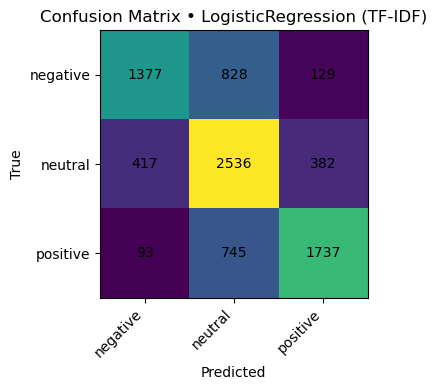

In [28]:
# Train LogisticRegression on TF-IDF and evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

logreg_tfidf = LogisticRegression(max_iter=2000, solver="sag")
logreg_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = logreg_tfidf.predict(X_test_tfidf)
print("Classification report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf, digits=4))

labels_sorted = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred_tfidf, labels=labels_sorted)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix • LogisticRegression (TF-IDF)")
plt.xticks(ticks=range(len(labels_sorted)), labels=labels_sorted, rotation=45, ha="right")
plt.yticks(ticks=range(len(labels_sorted)), labels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


In [29]:
# Most influential tokens for TF-IDF + LogisticRegression
import pandas as pd
import numpy as np

feature_names_tfidf = np.array(tfidf.get_feature_names_out())
classes = np.array(logreg_tfidf.classes_)
coef_tfidf = logreg_tfidf.coef_  # (n_classes, n_features)

def top_tokens_for_class(coef_row, feature_names, k=20):
    pos_idx = np.argsort(coef_row)[::-1][:k]   # strongest positive weights
    neg_idx = np.argsort(coef_row)[:k]         # strongest negative weights
    df_pos = pd.DataFrame({"token": feature_names[pos_idx], "weight": coef_row[pos_idx], "direction": "pro-class"})
    df_neg = pd.DataFrame({"token": feature_names[neg_idx], "weight": coef_row[neg_idx], "direction": "anti-class"})
    return pd.concat([df_pos, df_neg], ignore_index=True)

top_k = 20
top_tables_tfidf = {cls: top_tokens_for_class(coef_tfidf[i], feature_names_tfidf, k=top_k)
                    for i, cls in enumerate(classes)}

for cls, tbl in top_tables_tfidf.items():
    print(f"\n=== Class (TF-IDF): {cls} ===")
    display(tbl.sort_values(["direction", "weight"], ascending=[False, False]))



=== Class (TF-IDF): negative ===


,token,weight,direction
0,sad,5.058740,pro-class
1,miss,4.993703,pro-class
2,sorri,4.631534,pro-class
3,hate,4.467307,pro-class
4,suck,4.250533,pro-class
5,bore,3.750978,pro-class
6,fail,3.521128,pro-class
7,stupid,3.336949,pro-class
8,sick,3.248166,pro-class
9,bad,3.126641,pro-class



=== Class (TF-IDF): neutral ===


,token,weight,direction
0,indoor,1.243339,pro-class
1,guitar,1.216229,pro-class
2,moro,1.122498,pro-class
3,avail,1.039007,pro-class
4,grade,1.007446,pro-class
5,there,0.996269,pro-class
6,how,0.981000,pro-class
7,jst,0.976328,pro-class
8,mmm,0.974022,pro-class
9,differ,0.965052,pro-class



=== Class (TF-IDF): positive ===


,token,weight,direction
0,love,6.718336,pro-class
1,thank,5.649698,pro-class
2,awesom,4.743177,pro-class
3,great,4.561007,pro-class
4,good,4.461119,pro-class
5,happi,4.396139,pro-class
6,nice,4.338267,pro-class
7,hope,4.103892,pro-class
8,amaz,3.816654,pro-class
9,excit,3.794974,pro-class


In [30]:
# Additional -  Compare top tokens TF-IDF vs BoW for 'positive'

try:
    feature_names_bow = np.array(vectorizer_b2.get_feature_names_out())
    coef_bow = logreg.coef_
    classes_bow = np.array(logreg.classes_)
    idx_pos_tfidf = classes.tolist().index("positive")
    idx_pos_bow   = classes_bow.tolist().index("positive")

    top_pos_tfidf = feature_names_tfidf[np.argsort(coef_tfidf[idx_pos_tfidf])[::-1][:20]]
    top_pos_bow   = feature_names_bow[np.argsort(coef_bow[idx_pos_bow])[::-1][:20]]

    print("Top positive tokens (TF-IDF):", list(top_pos_tfidf))
    print("Top positive tokens (BoW):   ", list(top_pos_bow))

    overlap = set(top_pos_tfidf).intersection(set(top_pos_bow))
    print(f"\nOverlap count: {len(overlap)}")
    print("Overlap tokens:", sorted(overlap))
except Exception as e:
    print("BoW objects not available for comparison:", e)


Top positive tokens (TF-IDF): ['love', 'thank', 'awesom', 'great', 'good', 'happi', 'nice', 'hope', 'amaz', 'excit', 'enjoy', 'cute', 'glad', 'fun', 'best', 'interest', 'yay', 'cool', 'bless', 'better']
Top positive tokens (BoW):    ['awesom', 'cute', 'thank', 'love', 'glad', 'amaz', 'nice', 'gorgeous', 'congratul', 'excit', 'enjoy', 'great', 'bless', 'congrat', 'fantast', 'happi', 'yummi', 'interest', 'yum', 'welcom']

Overlap count: 13
Overlap tokens: ['amaz', 'awesom', 'bless', 'cute', 'enjoy', 'excit', 'glad', 'great', 'happi', 'interest', 'love', 'nice', 'thank']


### Висновок (Завдання 6: TF-IDF vs BoW, LogisticRegression)

Порівняння якості (ті самі train/test індекси):  
- BoW + LogReg: Accuracy ≈ 0.6862, F1_macro ≈ 0.6867  
- TF-IDF + LogReg: Accuracy ≈ 0.6853, F1_macro ≈ 0.6847  
Різниця дуже мала і на користь BoW (≈ +0.002 F1_macro).

По класах (F1):  
- negative: 0.656 -> 0.653 (трохи гірше з TF-IDF, падає recall ~0.59)  
- neutral: 0.673 -> 0.681 (TF-IDF трохи краще; recall ~0.76 проти ~0.72)  
- positive: 0.731 -> 0.720 (TF-IDF трохи гірше)

Важливі токени:  
- Обидві векторизації виділяють очікувані емоційні маркери:  
  - positive: *love, thank, awesom(e), great, good, happi, nice, excit, enjoy…*  
  - negative: *sad, miss, sorri, hate, suck, bore, fail, stupid, sick, bad…*  
- Перетин позитивних токенів: 13 зі 20 збігаються між TF-IDF і BoW  
- TF-IDF сильніше підкреслює рідші/специфічні слова та занижує ваги частих

Висновок/вибір:  
Для поточних налаштувань BoW + LogisticRegression дає трохи вищу F1_macro і простіше інтерпретується - тому для конкретної задачі обираю його.  
TF-IDF має сенс, якщо:  
- додати біграми (*ngram_range=(1,2)*)  
- підкрутити *min_df/max_df*   

Можливо, тоді TF-IDF часто вирівнює класи й дає приріст, особливо для *neutral*.


### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [33]:
# Collect TF-IDF errors and basic stats
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

proba_tfidf = logreg_tfidf.predict_proba(X_test_tfidf)  # (n_samples, n_classes)
class_order = list(logreg_tfidf.classes_)

test_df = df.iloc[test_idx].copy()
test_df = test_df.assign(
    true=y_test,
    pred=y_pred_tfidf,
    correct=(y_test == y_pred_tfidf),
    pred_prob=np.take_along_axis(proba_tfidf,
                                 np.array([class_order.index(c) for c in y_pred_tfidf]).reshape(-1,1),
                                 axis=1).ravel()
)

errors = test_df[~test_df["correct"]].copy()
print(f"Errors: {len(errors)} / {len(test_df)}  ({len(errors)/len(test_df):.2%})")

# Confusion breakdown table
cm = confusion_matrix(y_test, y_pred_tfidf, labels=class_order)
pd.DataFrame(cm, index=[f"true_{c}" for c in class_order], columns=[f"pred_{c}" for c in class_order])


Errors: 2594 / 8244  (31.47%)


,pred_negative,pred_neutral,pred_positive
true_negative,1377,828,129
true_neutral,417,2536,382
true_positive,93,745,1737


In [34]:
# Most confident mistakes overall (high predicted prob but wrong)
top_k = 20
confident_err = errors.sort_values("pred_prob", ascending=False).head(top_k)
confident_err[["text", "true", "pred", "pred_prob"]]


,text,true,pred,pred_prob
7190,not so good,negative,positive,0.993776
18230,__ that`s not good! hope you get better soon ...,neutral,positive,0.992654
983,I sorry,positive,negative,0.989387
20224,"Yes thanks, its been great. Soooooo not look...",neutral,positive,0.989349
8130,Well that just sucks. Good way to make me feel...,neutral,negative,0.982315
5994,haha! I remember that! That trip was fun. I M...,neutral,negative,0.974880
3131,Happy its the weekend...LOVE has knocked me do...,neutral,positive,0.974353
12445,is feeling Fab today and missing my boo,neutral,negative,0.974036
10906,nice have fun....Although you cant not have f...,neutral,positive,0.971383
15245,_hope why?,neutral,positive,0.970393


In [35]:
#  Error examples per pair(true -> pred)
def pair_examples(true_cls, pred_cls, k=8, by="pred_prob"):
    subset = errors[(errors["true"]==true_cls) & (errors["pred"]==pred_cls)]
    return subset.sort_values(by, ascending=False).head(k)[["text","true","pred","pred_prob"]]

ex_neu_pos = pair_examples("neutral", "positive", 8)
ex_neu_neg = pair_examples("neutral", "negative", 8)
ex_pos_neu = pair_examples("positive", "neutral", 8)
ex_neg_neu = pair_examples("negative", "neutral", 8)

ex_neu_pos, ex_neu_neg, ex_pos_neu, ex_neg_neu


(                                                    text     true      pred  \
 18230  __  that`s not good! hope you get better soon ...  neutral  positive   
 20224    Yes thanks, its been great. Soooooo not look...  neutral  positive   
 3131   Happy its the weekend...LOVE has knocked me do...  neutral  positive   
 10906   nice have fun....Although you cant not have f...  neutral  positive   
 15245                                         _hope why?  neutral  positive   
 3324             Should I say goodnight or good morning?  neutral  positive   
 5834    haha nice! I heard it`s a sweet hotel. On ano...  neutral  positive   
 11971   awww  well I am here...just in case...I am no...  neutral  positive   
 
        pred_prob  
 18230   0.992654  
 20224   0.989349  
 3131    0.974353  
 10906   0.971383  
 15245   0.970393  
 3324    0.954791  
 5834    0.954590  
 11971   0.954143  ,
                                                     text     true      pred  \
 8130   Well that

In [36]:
# See influential tokens present in a given mistaken tweet
import numpy as np
import pandas as pd
from IPython.display import display

feat_names = np.array(tfidf.get_feature_names_out())
coef = logreg_tfidf.coef_                   # (n_classes, n_features)
class_order = list(logreg_tfidf.classes_)   # ensure defined
cls_to_idx = {c: i for i, c in enumerate(class_order)}

def explain_example(idx_in_test, top=10):
    """Return tokens in this tweet with largest weights toward the PREDICTED class."""
    row = X_test_tfidf[idx_in_test]
    pred_cls = y_pred_tfidf[idx_in_test]
    pred_ci = cls_to_idx[pred_cls]

    # active features for this tweet
    nz = row.nonzero()[1]
    if nz.size == 0:
        return pd.DataFrame({"token": [], "coef(pred_cls)":[]})

    weights = coef[pred_ci, nz]
    order = np.argsort(weights)[::-1][:top]
    toks = feat_names[nz[order]]
    vals = weights[order]
    return pd.DataFrame({"token": toks, "coef(pred_cls)": vals})

# If there are no errors, say so explicitly
if 'errors' not in globals() or len(errors) == 0:
    print("No test errors — nothing to explain.")
else:
    # Most confident wrong prediction
    err_row = errors.sort_values("pred_prob", ascending=False).iloc[0]
    orig_idx = err_row.name  # original df index

    # Robust mapping to position within the test set
    try:
        pos_in_test = test_df.index.get_loc(orig_idx)
    except KeyError:
        # fallback if indices were reset somewhere
        pos_in_test = int(np.where(test_idx == orig_idx)[0][0])

    print(f"Most confident error: true={err_row['true']}, pred={err_row['pred']}, "
          f"prob={err_row['pred_prob']:.3f}")
    display(pd.DataFrame({"text":[err_row["text"]]}))
    expl = explain_example(pos_in_test, top=12)

    if expl.empty:
        print("No active TF-IDF features for this tweet (all tokens filtered).")
    else:
        display(expl)


Most confident error: true=negative, pred=positive, prob=0.994


,text
0,not so good


,token,coef(pred_cls)
0,good,4.461119


In [37]:
# Aggregates for error patterns
test_df["len"] = test_df["text"].str.len()
agg = (
    test_df
    .assign(bucket=pd.cut(test_df["len"], bins=[0,30,60,90,120,999], include_lowest=True))
    .groupby("bucket", observed=True)["correct"].mean()
    .rename("accuracy")
)
print(agg, errors["true"].value_counts(), errors["pred"].value_counts())


bucket
(-0.001, 30.0]    0.800000
(30.0, 60.0]      0.731922
(60.0, 90.0]      0.646130
(90.0, 120.0]     0.616005
(120.0, 999.0]    0.586022
Name: accuracy, dtype: float64 true
negative    957
positive    838
neutral     799
Name: count, dtype: int64 pred
neutral     1573
positive     511
negative     510
Name: count, dtype: int64


### Висновок

Загалом: 2594/8244 тестових прикладів класифіковано неправильно (31.5%).

Де саме помиляється модель:  
- `Neutral`: на нього припадає найбільше хибних передбачень (≈ 1 573 з усіх помилок).  
  Типові кейси: короткі чи описові твіти без виразних маркерів емоцій або тексти з поодинокими емоційними словами без контексту.  
- Плутанина пар: `neutral - positive` і `neutral - negative` — головні джерела помилок.  
  Часто positive - neutral (навіть з високою впевненістю) та negative - neutral.  
- Змішані формулювання: приклади на прикллад “not so good” класифікуються як positive (ігнорується заперечення).  
  Так само нейтральні повідомлення з одним словом “love/thanks” - positive, або з “sucks/hate” - negative.  
- Довжина тексту: точність падає із зростанням довжини  
  (до 30 символів ≈ 0.80, 30–60 ≈ 0.73, 60–90 ≈ 0.65, 90–120 ≈ 0.62, >120 ≈ 0.59).  
  Довші твіти частіше містять змішані сигнали й більше шуму.

3 шляхи поліпшення якості:  
1. Краще моделювати контекст і заперечення  
   - Додати n-грами слів: у TF-IDF - це покриє шаблони типу *“not good”, “no way”, “can’t wait”*.  
   - Нормалізувати апострофи (*don't -> do not*), обробляти розтягнуті слова (*soooo -> so*), мапити емодзі/смайли на токени настрою.  

2. Збагатити ознаки для коротких та “шумних” текстів  
   - Додати символьні n-грами TF-IDF (3–5) разом зі словесними - стійкіші до опечаток і сленгу.  
   - Підібрати частотні фільтри `min_df` та `max_df` і розмір словника, щоб зняти рідкісні артефакти та зайві часті токени.  

3. Тюнінг моделі та баланс класів  
   - Підібрати гіперпараметр `C` для LogisticRegression; спробувати LinearSVC.  
   - Використати `class_weight='balanced'`для зменшення зсуву в бік `neutral`.  
   - Провести k-fold CV із фіксованими індексами train/test для стабільної оцінки.  


І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model